The aim of this notebook is to explore which target shapes can or cannot be learned by a PINned model.

In [2]:
%load_ext autoreload
%autoreload 2

In [17]:
import numpy as np

N = 500
T = 10.5
dt = 0.001
sigma = np.sqrt(0.3)
epsilon = 0.05
neuron_list = [0, 100, 200, 300, 400, 499]
max_bumps = 4

p = 0.08
g = 1.2
tau = 0.01
theta = 0
p0 = 10
n_runs = 500
n_steps = 50
cv_threshold = 0.0
p_reg = 1e-9

eval_threshold = 0.95

# Inputs generation

In [9]:
from src.inputs_generation import Inputs

WN_tau = 1
h0 = 0.15

ipt = Inputs(T, dt)
inputs = ipt.inputs(N, WN_tau, h0)

# Type 1: Random firing gaussian sequences

In [ ]:
from src.targets_generation import Random_firing_gaussian_seq
from src.training import RNN, PINning
from src.evaluation import Metrics
from scipy.special import expit

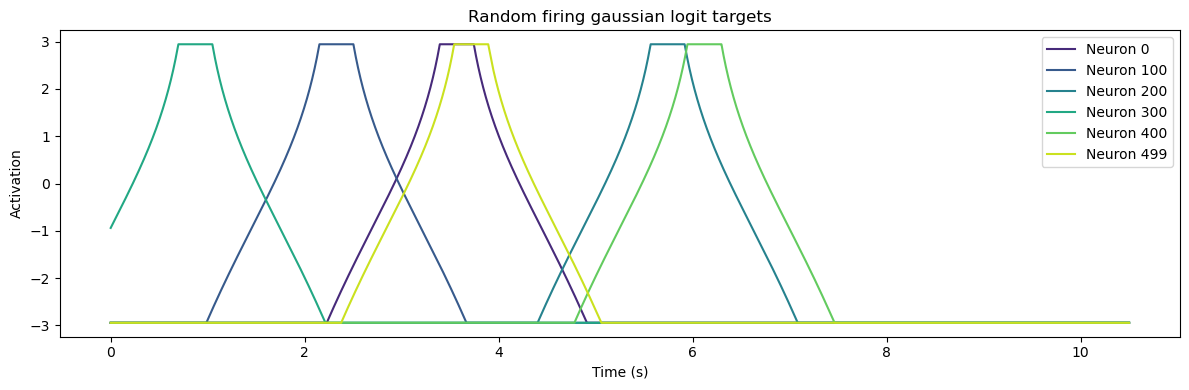

In [ ]:
rfgs = Random_firing_gaussian_seq(T, dt)
targets = rfgs.target_functions(T, sigma, N, epsilon)
rfgs.target_graph(T, sigma, N, neuron_list, epsilon)

Run 1 | run_error=0.026747 | ||J||=313.14 | Δ||J||=+0.00
Run 2 | run_error=0.058618 | ||J||=378.85 | Δ||J||=+65.70
Run 3 | run_error=0.047223 | ||J||=408.11 | Δ||J||=+29.27
Run 4 | run_error=0.040412 | ||J||=426.60 | Δ||J||=+18.48
Run 5 | run_error=0.033308 | ||J||=446.11 | Δ||J||=+19.52
Run 6 | run_error=0.032109 | ||J||=451.93 | Δ||J||=+5.81
Run 7 | run_error=0.037751 | ||J||=467.23 | Δ||J||=+15.30
Run 8 | run_error=0.031645 | ||J||=475.24 | Δ||J||=+8.01
Run 9 | run_error=0.025984 | ||J||=481.63 | Δ||J||=+6.40
Run 10 | run_error=0.024674 | ||J||=486.73 | Δ||J||=+5.10
Run 11 | run_error=0.024264 | ||J||=491.68 | Δ||J||=+4.95
Run 12 | run_error=0.027733 | ||J||=495.96 | Δ||J||=+4.28
Run 13 | run_error=0.027480 | ||J||=500.29 | Δ||J||=+4.32
Run 14 | run_error=0.032566 | ||J||=503.58 | Δ||J||=+3.29
Run 15 | run_error=0.023355 | ||J||=505.55 | Δ||J||=+1.96
Run 16 | run_error=0.024041 | ||J||=507.74 | Δ||J||=+2.19
Run 17 | run_error=0.022307 | ||J||=509.74 | Δ||J||=+2.00
Run 18 | run_error

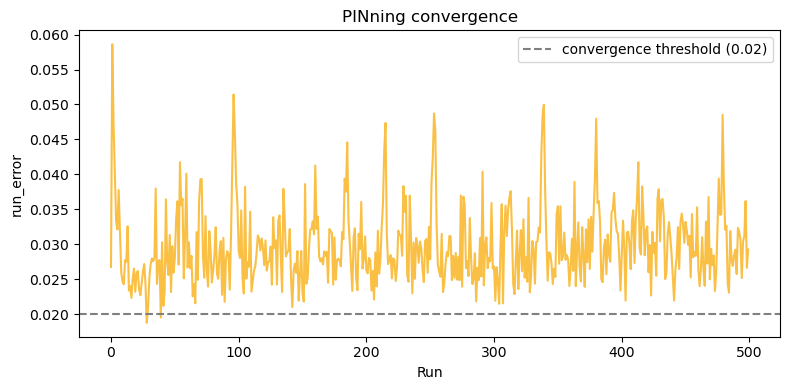

In [ ]:
rnn = RNN(N, g, dt, tau, theta, p0)
PINned_model = PINning(p, rnn, targets, p0)
errors, j_norms = PINned_model.train(inputs, n_runs, cv_threshold, DEBUG = True, p_reg=p_reg) # approx 10min
PINned_model.display_cv(errors)

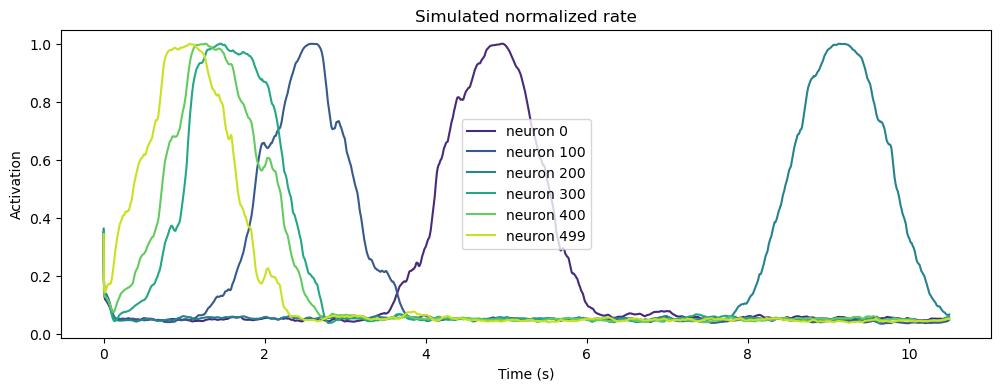

In [ ]:
final_rates = PINned_model.simulate(inputs, n_steps=n_steps)
PINned_model.display_simulation(T, dt, final_rates, neuron_list)

In [ ]:
targets_rate = expit(targets)
Metrics.general_evaluation(rates = final_rates, targets = targets_rate, t = rfgs.t, sigma = sigma, threshold = eval_threshold)

,,bVar,pVar,Qeff
0,Model's metrics,0.718375,0.982671,9
1,Article's metrics for p=0.08,1,0.92,10


Conclusion: Models succeeds.

# Type 2: Multiple gaussian sequences

In [16]:
from src.targets_generation import Multiple_gaussian_seq
from src.training import RNN, PINning
from src.evaluation import Metrics
from scipy.special import expit

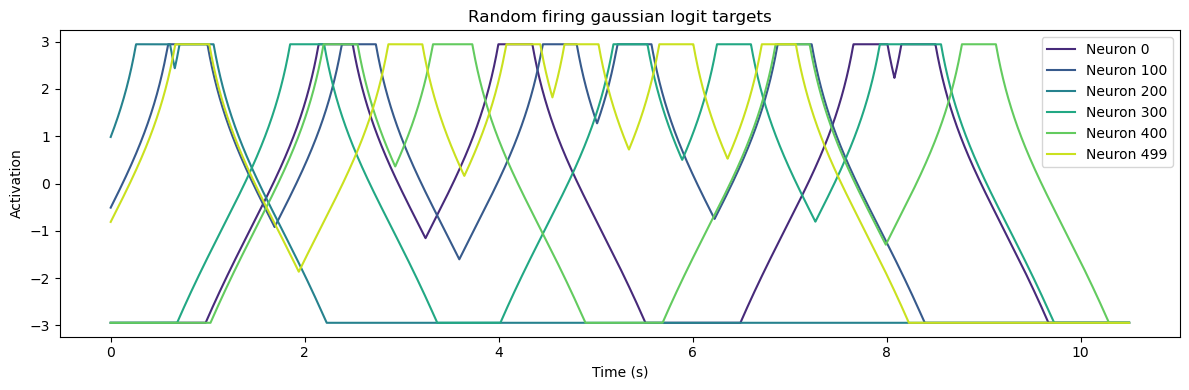

In [44]:
mgs = Multiple_gaussian_seq(T, dt)
targets = mgs.target_functions(T, sigma, N, epsilon, max_bumps)
mgs.target_graph(T, sigma, N, neuron_list, epsilon)

Run 1 | run_error=0.059636 | ||J||=480.11 | Δ||J||=+0.00
Run 2 | run_error=0.109954 | ||J||=556.32 | Δ||J||=+76.22
Run 3 | run_error=0.093839 | ||J||=605.90 | Δ||J||=+49.58
Run 4 | run_error=0.069128 | ||J||=639.67 | Δ||J||=+33.77
Run 5 | run_error=0.061196 | ||J||=666.49 | Δ||J||=+26.82
Run 6 | run_error=0.061835 | ||J||=687.58 | Δ||J||=+21.09
Run 7 | run_error=0.062199 | ||J||=707.83 | Δ||J||=+20.25
Run 8 | run_error=0.061004 | ||J||=726.56 | Δ||J||=+18.73
Run 9 | run_error=0.056272 | ||J||=742.40 | Δ||J||=+15.84
Run 10 | run_error=0.048760 | ||J||=754.79 | Δ||J||=+12.39
Run 11 | run_error=0.050109 | ||J||=768.41 | Δ||J||=+13.63
Run 12 | run_error=0.044249 | ||J||=781.18 | Δ||J||=+12.77
Run 13 | run_error=0.048484 | ||J||=789.56 | Δ||J||=+8.38
Run 14 | run_error=0.051890 | ||J||=799.47 | Δ||J||=+9.90
Run 15 | run_error=0.048470 | ||J||=804.88 | Δ||J||=+5.41
Run 16 | run_error=0.048974 | ||J||=812.25 | Δ||J||=+7.37
Run 17 | run_error=0.047091 | ||J||=820.30 | Δ||J||=+8.05
Run 18 | run

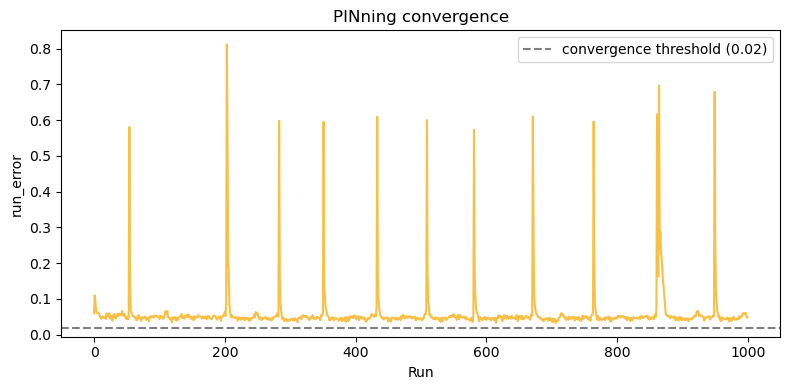

In [ ]:
rnn = RNN(N, g, dt, tau, theta, p0)
PINned_model = PINning(p, rnn, targets, p0)
errors, j_norms = PINned_model.train(inputs, n_runs=1000, cv_threshold=cv_threshold, DEBUG = True, p_reg=p_reg)
PINned_model.display_cv(errors)

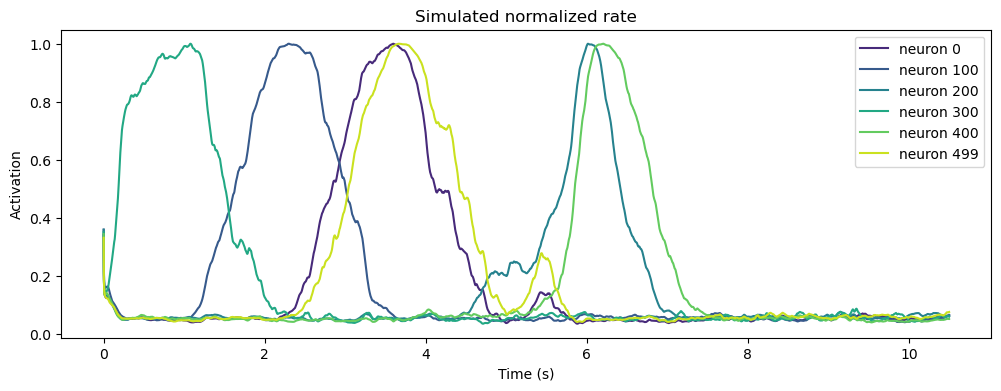

In [20]:
final_rates = PINned_model.simulate(inputs, n_steps=n_steps)
PINned_model.display_simulation(T, dt, final_rates, neuron_list)

In [21]:
targets_rate = expit(targets)
Metrics.general_evaluation(rates = final_rates, targets = targets_rate, t = mgs.t, sigma = sigma, threshold = eval_threshold)

,,bVar,pVar,Qeff
0,Model's metrics,0.616226,0.919066,9
1,Article's metrics for p=0.08,1,0.92,10


Conclusion: Model struggles.

# Type 3: Constant activity allowed

In [4]:
from src.targets_generation import Active_unactive_seq
from src.training import RNN, PINning
from src.evaluation import Metrics
from scipy.special import expit

In [5]:
max_bumps = 1

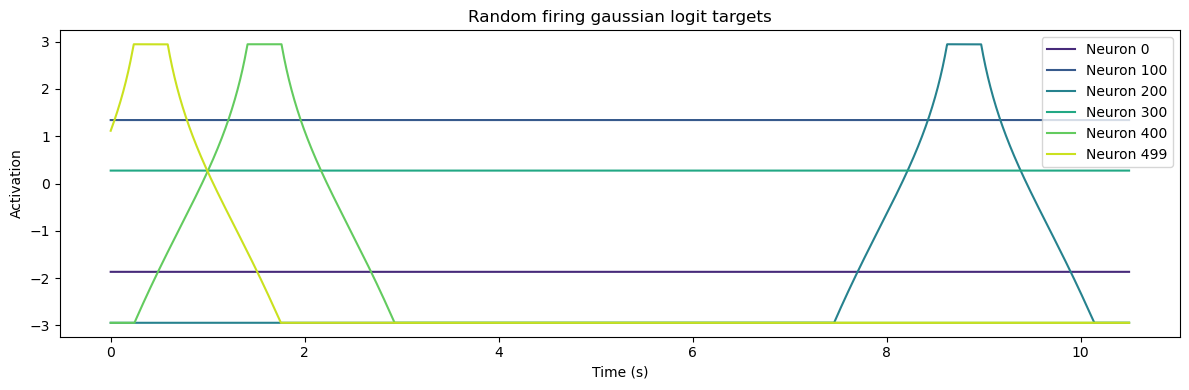

In [6]:
aus = Active_unactive_seq(T, dt)
targets = aus.target_functions(T, sigma, N, epsilon, max_bumps)
aus.target_graph(T, sigma, N, neuron_list, epsilon)

Run 1 | run_error=0.048047 | ||J||=710.18 | Δ||J||=+0.00
Run 2 | run_error=0.049143 | ||J||=847.29 | Δ||J||=+137.11
Run 3 | run_error=0.041668 | ||J||=901.78 | Δ||J||=+54.49
Run 4 | run_error=0.032444 | ||J||=945.53 | Δ||J||=+43.74
Run 5 | run_error=0.032617 | ||J||=975.53 | Δ||J||=+30.00
Run 6 | run_error=0.027639 | ||J||=994.10 | Δ||J||=+18.57
Run 7 | run_error=0.028587 | ||J||=1016.28 | Δ||J||=+22.18
Run 8 | run_error=0.026765 | ||J||=1029.90 | Δ||J||=+13.62
Run 9 | run_error=0.027981 | ||J||=1046.22 | Δ||J||=+16.31
Run 10 | run_error=0.030224 | ||J||=1062.72 | Δ||J||=+16.50
Run 11 | run_error=0.028758 | ||J||=1076.90 | Δ||J||=+14.19
Run 12 | run_error=0.026512 | ||J||=1087.75 | Δ||J||=+10.84
Run 13 | run_error=0.025336 | ||J||=1099.46 | Δ||J||=+11.71
Run 14 | run_error=0.025920 | ||J||=1108.21 | Δ||J||=+8.75
Run 15 | run_error=0.024156 | ||J||=1117.17 | Δ||J||=+8.95
Run 16 | run_error=0.025341 | ||J||=1125.29 | Δ||J||=+8.13
Run 17 | run_error=0.024202 | ||J||=1132.87 | Δ||J||=+7.58

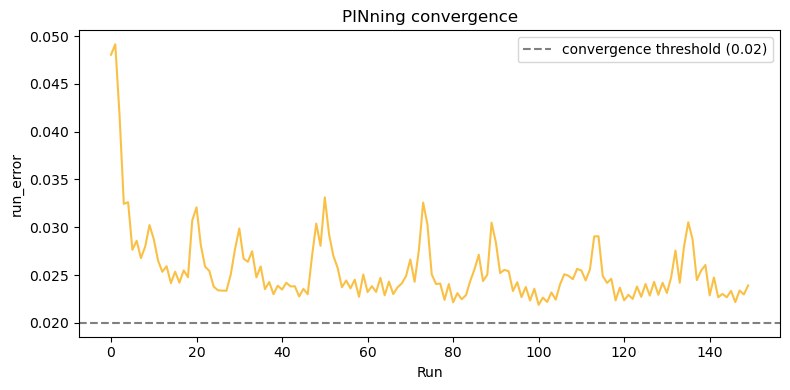

In [7]:
rnn = RNN(N, g, dt, tau, theta, p0)
PINned_model = PINning(p, rnn, targets, p0)
errors, j_norms = PINned_model.train(inputs, n_runs=150, cv_threshold=cv_threshold, DEBUG = True, p_reg=p_reg)
PINned_model.display_cv(errors)

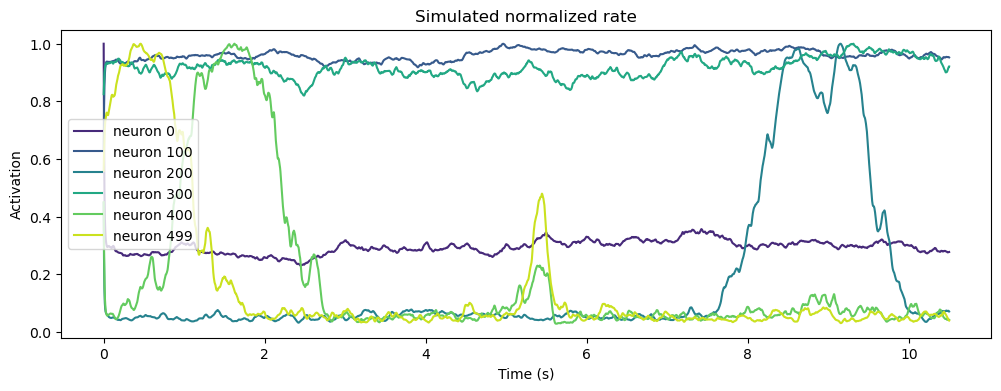

In [8]:
final_rates = PINned_model.simulate(inputs, n_steps=n_steps)
PINned_model.display_simulation(T, dt, final_rates, neuron_list)

In [10]:
targets_rate = expit(targets)
Metrics.general_evaluation(rates = final_rates, targets = targets_rate, t = aus.t, sigma = sigma, threshold = eval_threshold)

,,bVar,pVar,Qeff
0,Model's metrics,-0.75731,0.645184,9
1,Article's metrics for p=0.08,1,0.92,10


Conclusion: Pretty good, the model identifies the constant neurons and correctly places the activation bumps of the active ones.

# Type 4: Constant activity & multiple gaussian allowed

In [11]:
from src.targets_generation import Active_unactive_seq
from src.training import RNN, PINning
from src.evaluation import Metrics
from scipy.special import expit

In [12]:
max_bumps = 3

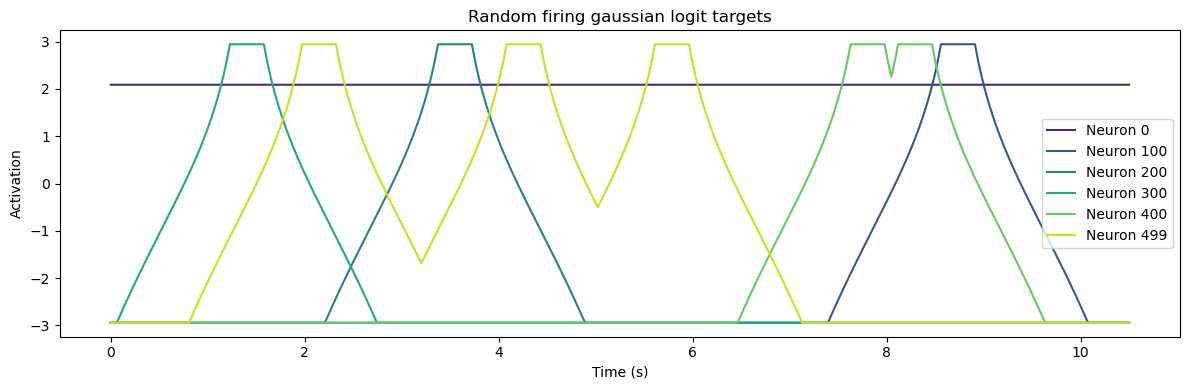

In [15]:
maus = Active_unactive_seq(T, dt)
targets = maus.target_functions(T, sigma, N, epsilon, max_bumps)
maus.target_graph(T, sigma, N, neuron_list, epsilon)

Run 1 | run_error=0.031405 | ||J||=345.42 | Δ||J||=+0.00
Run 2 | run_error=0.086407 | ||J||=474.09 | Δ||J||=+128.67
Run 3 | run_error=0.066214 | ||J||=519.04 | Δ||J||=+44.95
Run 4 | run_error=0.056069 | ||J||=547.47 | Δ||J||=+28.43
Run 5 | run_error=0.061966 | ||J||=566.19 | Δ||J||=+18.72
Run 6 | run_error=0.055821 | ||J||=587.86 | Δ||J||=+21.67
Run 7 | run_error=0.051751 | ||J||=596.25 | Δ||J||=+8.38
Run 8 | run_error=0.048067 | ||J||=612.56 | Δ||J||=+16.31
Run 9 | run_error=0.043375 | ||J||=617.39 | Δ||J||=+4.83
Run 10 | run_error=0.046868 | ||J||=632.50 | Δ||J||=+15.11
Run 11 | run_error=0.041828 | ||J||=637.33 | Δ||J||=+4.83
Run 12 | run_error=0.045762 | ||J||=647.69 | Δ||J||=+10.36
Run 13 | run_error=0.041890 | ||J||=653.15 | Δ||J||=+5.46
Run 14 | run_error=0.043054 | ||J||=658.52 | Δ||J||=+5.37
Run 15 | run_error=0.038066 | ||J||=662.22 | Δ||J||=+3.70
Run 16 | run_error=0.041184 | ||J||=667.95 | Δ||J||=+5.72
Run 17 | run_error=0.043654 | ||J||=672.88 | Δ||J||=+4.94
Run 18 | run_e

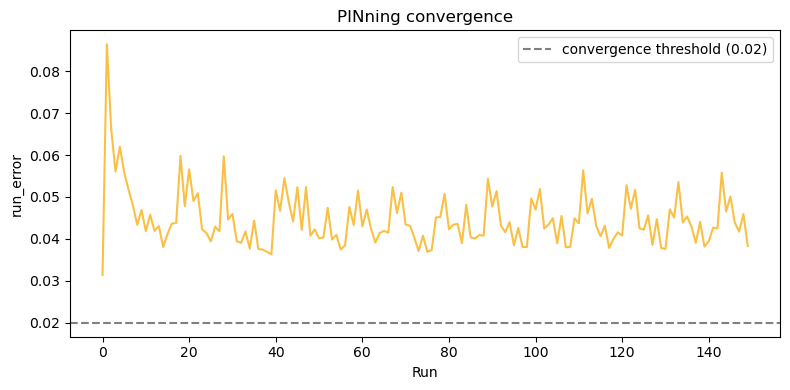

In [16]:
rnn = RNN(N, g, dt, tau, theta, p0)
PINned_model = PINning(p, rnn, targets, p0)
errors, j_norms = PINned_model.train(inputs, n_runs=150, cv_threshold=cv_threshold, DEBUG = True, p_reg=p_reg)
PINned_model.display_cv(errors)

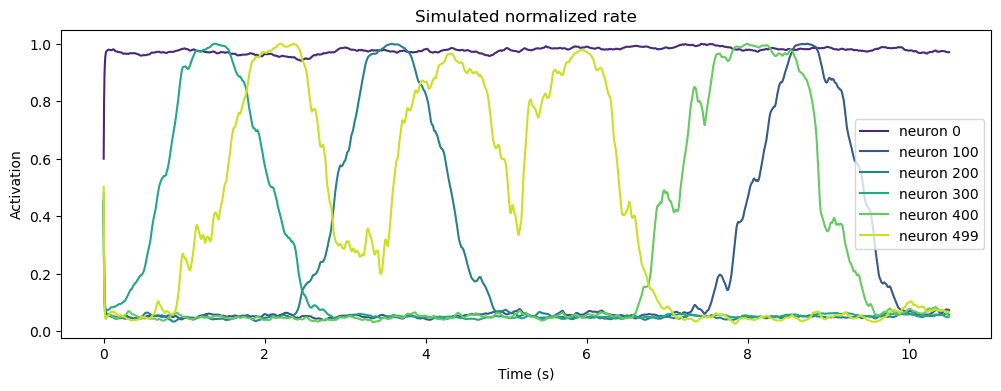

In [17]:
final_rates = PINned_model.simulate(inputs, n_steps=n_steps)
PINned_model.display_simulation(T, dt, final_rates, neuron_list)

In [18]:
targets_rate = expit(targets)
Metrics.general_evaluation(rates = final_rates, targets = targets_rate, t = maus.t, sigma = sigma, threshold = eval_threshold)

,,bVar,pVar,Qeff
0,Model's metrics,-0.479124,0.828825,10
1,Article's metrics for p=0.08,1,0.92,10


Conclusion: Very good!

# Type 5: Indicator sequences

In [32]:
from src.targets_generation import Indicator_seq
from src.training import RNN, PINning
from src.evaluation import Metrics
from scipy.special import expit

In [33]:
width_range=(0.3, 3.5)

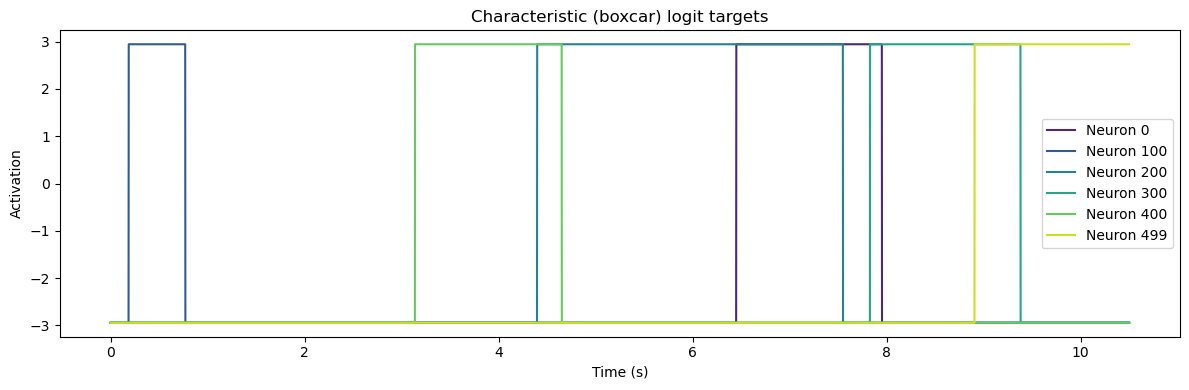

In [34]:
ind = Indicator_seq(T, dt)
targets = ind.target_functions(T, sigma, N, epsilon, width_range)
ind.target_graph(T, sigma, N, neuron_list, epsilon)

Run 1 | run_error=0.442836 | ||J||=177.88 | Δ||J||=+0.00
Run 2 | run_error=0.462390 | ||J||=187.34 | Δ||J||=+9.46
Run 3 | run_error=0.764274 | ||J||=188.68 | Δ||J||=+1.34
Run 4 | run_error=0.696786 | ||J||=192.89 | Δ||J||=+4.22
Run 5 | run_error=0.599760 | ||J||=194.92 | Δ||J||=+2.03
Run 6 | run_error=0.549450 | ||J||=200.70 | Δ||J||=+5.78
Run 7 | run_error=0.624093 | ||J||=202.35 | Δ||J||=+1.64
Run 8 | run_error=0.626215 | ||J||=205.42 | Δ||J||=+3.07
Run 9 | run_error=0.591423 | ||J||=206.55 | Δ||J||=+1.13
Run 10 | run_error=0.600255 | ||J||=207.49 | Δ||J||=+0.94
Run 11 | run_error=0.606254 | ||J||=209.79 | Δ||J||=+2.30
Run 12 | run_error=0.635256 | ||J||=213.28 | Δ||J||=+3.49
Run 13 | run_error=0.560622 | ||J||=215.32 | Δ||J||=+2.03
Run 14 | run_error=0.580730 | ||J||=217.91 | Δ||J||=+2.60
Run 15 | run_error=0.556709 | ||J||=220.70 | Δ||J||=+2.79
Run 16 | run_error=0.609093 | ||J||=223.21 | Δ||J||=+2.51
Run 17 | run_error=0.503477 | ||J||=225.05 | Δ||J||=+1.84
Run 18 | run_error=0.56

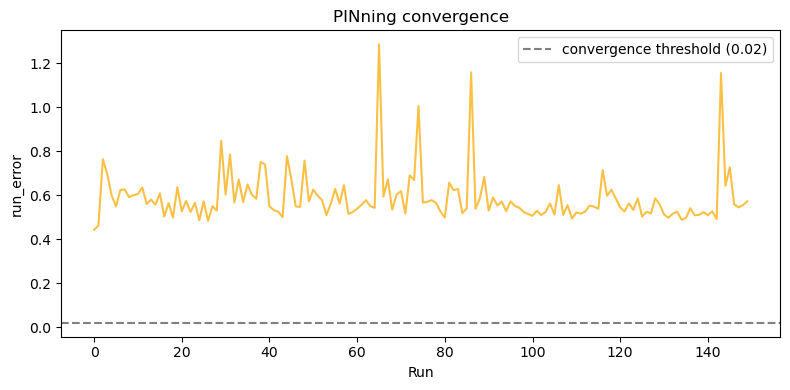

In [35]:
rnn = RNN(N, g, dt, tau, theta, p0)
PINned_model = PINning(p, rnn, targets, p0)
errors, j_norms = PINned_model.train(inputs, n_runs=150, cv_threshold=cv_threshold, DEBUG = True, p_reg=p_reg)
PINned_model.display_cv(errors)

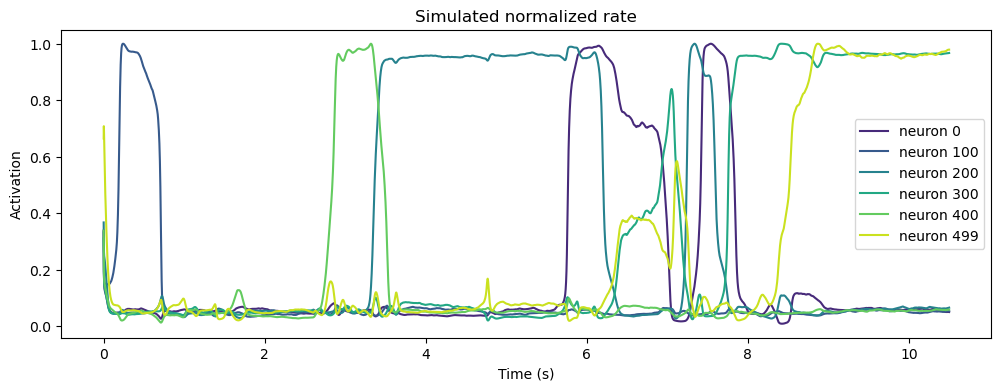

In [36]:
final_rates = PINned_model.simulate(inputs, n_steps=n_steps)
PINned_model.display_simulation(T, dt, final_rates, neuron_list)

In [37]:
targets_rate = expit(targets)
Metrics.general_evaluation(rates = final_rates, targets = targets_rate, t = ind.t, sigma = sigma, threshold = eval_threshold)

,,bVar,pVar,Qeff
0,Model's metrics,0.322711,0.28526,10
1,Article's metrics for p=0.08,1,0.92,10


Conclusion: Surprisingly seems to work pretty well.

# Type 6: Grid cells sequences

In [13]:
from src.targets_generation import Grid_cells_seq
from src.training import RNN, PINning
from src.evaluation import Metrics
from scipy.special import expit

In [11]:
tCOM_list = [2, 5, 8] # must fit into T
n_steps = 300

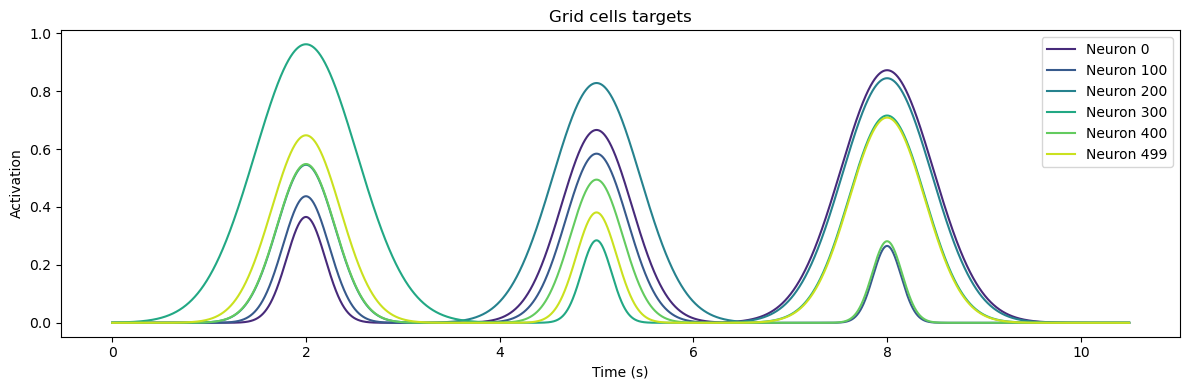

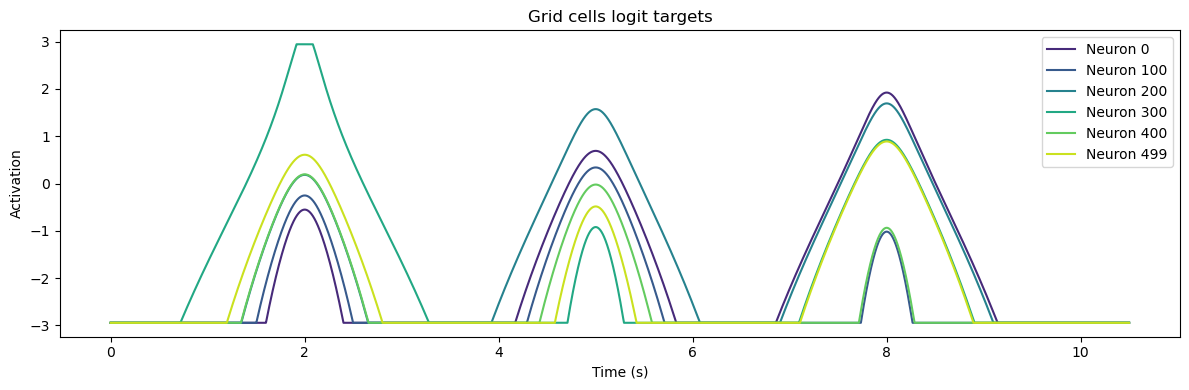

In [6]:
gcs = Grid_cells_seq(T, dt, tCOM_list)
targets = gcs.target_functions(T, sigma, N, epsilon)
gcs.gaussian_graph(T, sigma, N, neuron_list)
gcs.target_graph(T, sigma, N, neuron_list, epsilon)

Run 1 | run_error=0.434237 | ||J||=1774.48 | Δ||J||=+0.00
Run 2 | run_error=0.362118 | ||J||=1945.07 | Δ||J||=+170.58
Run 3 | run_error=0.283467 | ||J||=2086.71 | Δ||J||=+141.64
Run 4 | run_error=0.259393 | ||J||=2175.44 | Δ||J||=+88.73
Run 5 | run_error=0.229697 | ||J||=2265.59 | Δ||J||=+90.15
Run 6 | run_error=0.233242 | ||J||=2333.69 | Δ||J||=+68.10
Run 7 | run_error=0.241236 | ||J||=2398.63 | Δ||J||=+64.94
Run 8 | run_error=0.244339 | ||J||=2459.90 | Δ||J||=+61.27
Run 9 | run_error=0.204026 | ||J||=2513.21 | Δ||J||=+53.31
Run 10 | run_error=0.322782 | ||J||=2562.24 | Δ||J||=+49.03
Run 11 | run_error=0.214866 | ||J||=2603.34 | Δ||J||=+41.11
Run 12 | run_error=0.209625 | ||J||=2636.46 | Δ||J||=+33.11
Run 13 | run_error=0.241862 | ||J||=2664.97 | Δ||J||=+28.51
Run 14 | run_error=0.197060 | ||J||=2695.20 | Δ||J||=+30.24
Run 15 | run_error=0.209597 | ||J||=2722.78 | Δ||J||=+27.58
Run 16 | run_error=0.235616 | ||J||=2743.95 | Δ||J||=+21.17
Run 17 | run_error=0.226976 | ||J||=2775.25 | Δ|

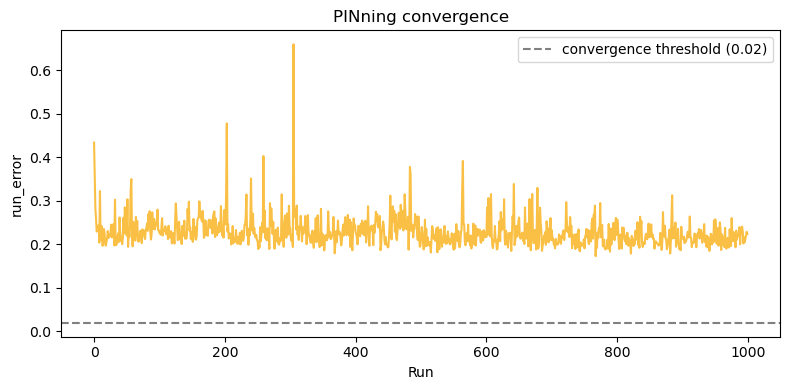

In [10]:
rnn = RNN(N, g, dt, tau, theta, p0)
PINned_model = PINning(p, rnn, targets, p0)
errors, j_norms = PINned_model.train(inputs, n_runs=1000, cv_threshold=cv_threshold, DEBUG = True, p_reg=p_reg)
PINned_model.display_cv(errors)

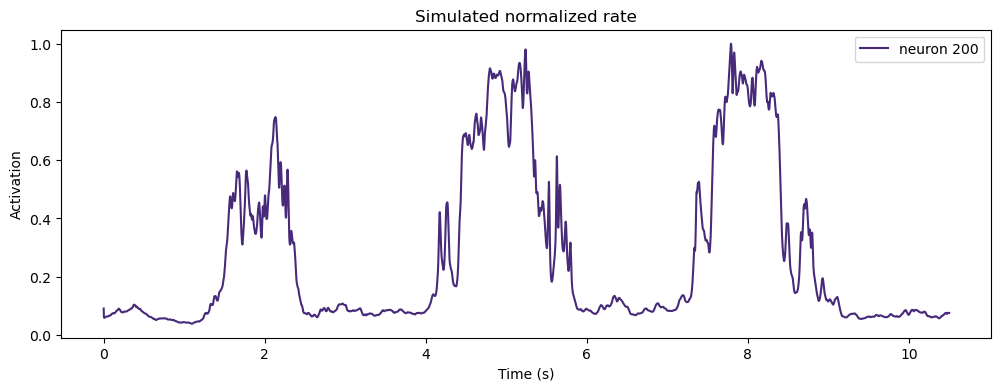

In [14]:
final_rates = PINned_model.simulate(inputs, n_steps)
PINned_model.display_simulation(T, dt, final_rates, neuron_list)

In [15]:
targets_rate = expit(targets)
Metrics.general_evaluation(rates = final_rates, targets = targets_rate, t = gcs.t, sigma = sigma, threshold = eval_threshold)

,,bVar,pVar,Qeff
0,Model's metrics,-2.908658,0.843613,3
1,Article's metrics for p=0.08,1,0.92,10


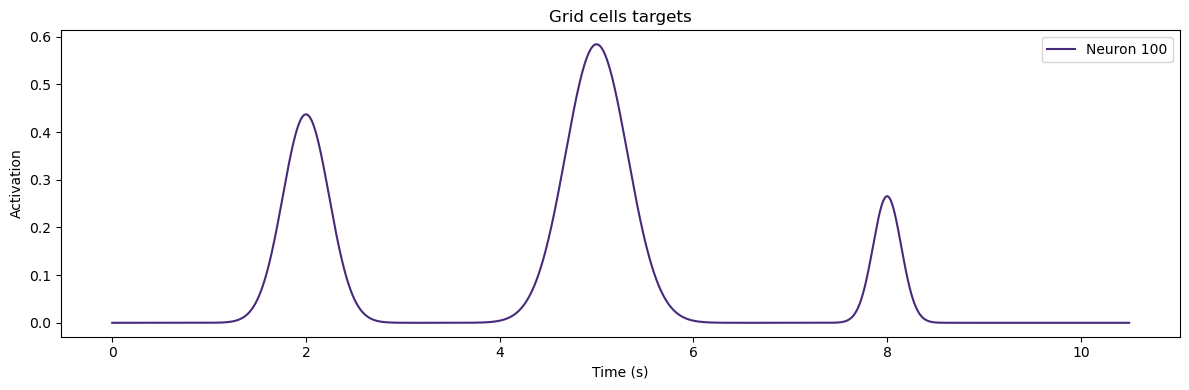

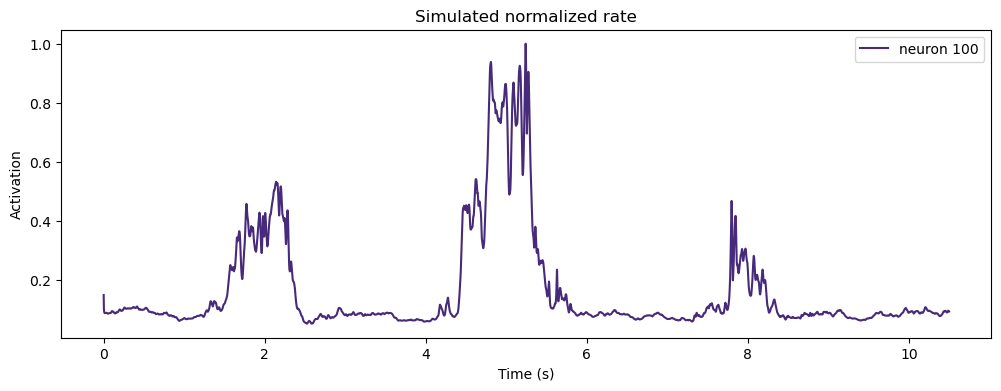

In [18]:
neuron_list = [100]
gcs.gaussian_graph(T, sigma, N, neuron_list)
PINned_model.display_simulation(T, dt, final_rates, neuron_list)